In [1]:
from pathlib import Path
import yaml, json

ROOT = Path.cwd()
DATA = ROOT / "data_yolo_dish"  # <- multi-dish dataset
assert (DATA/"train/images").exists(), "Missing train/images in data_yolo_dish"
assert (DATA/"val/images").exists() or (DATA/"valid/images").exists(), "Missing val/valid in data_yolo_dish"

val_key = "val" if (DATA/"val/images").exists() else "valid"
# names: keep your single "dish" or actual class list if you annotated per-class
# If your data_yolo_dish has class IDs aligned to class_names.json, do:
try:
    with open("class_names.json","r",encoding="utf-8") as f:
        NAMES = json.load(f)
except Exception:
    NAMES = ["dish"]  # fallback

yaml_dict = {
    "path": DATA.resolve().as_posix(),
    "train": "train/images",
    "val":   f"{val_key}/images",
    "names": NAMES
}
( DATA/"data.yaml" ).write_text(yaml.safe_dump(yaml_dict, sort_keys=False), encoding="utf-8")
print("Wrote", (DATA/"data.yaml").resolve())
print((DATA/"data.yaml").read_text())


Wrote C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\data.yaml
path: C:/Users/Jun Wei/Desktop/SIT/SIT Y2T1/Computer Vision and Deep Learning/Proj/food_classifier/data_yolo_dish
train: train/images
val: valid/images
names:
- Braised Crucian Carp
- Braised Pork
- Dry Pot Cauliflower
- Egg Drop Soup
- Fish Flavored Shredded Pork
- Fish Head Tofu Soup
- Fragrant Soy-sauced Eggplant
- Fried Milk Custard
- Glass Noodles with Minced Pork
- Hot and Sour Lotus Root Slices
- Kung Pao Chicken
- Scallion Oil Noodles
- Spicy Chongqing Hotpot
- Spicy Crab
- Spicy Tofu
- Steamed Pork with Rice Flour
- Stir-fried Pork Kidney
- Stir-fried Shredded Potatoes
- Tomato Scrambled Eggs
- Winter Melon Pork Rib Soup



In [2]:
from ultralytics import YOLO
import torch
from pathlib import Path

DATA_YAML = Path("data_yolo_dish/data.yaml")
assert DATA_YAML.exists()

# Start from a strong pretrain but small backbone (n or s).
# With 200 images, try yolov8n first; if underfitting, switch to yolov8s.
model = YOLO("yolov8n.pt")

model = YOLO("yolov8n.pt")
results = model.train(
    data="data_yolo_dish/data.yaml",
    imgsz=768,
    epochs=80,
    batch=16,
    patience=20,
    name="train_dishdet_multi",
    lr0=0.01, lrf=0.1,
    mosaic=1.0, mixup=0.2, copy_paste=0.3,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    translate=0.1, scale=0.5, fliplr=0.5,
    erasing=0.2, cos_lr=True, amp=True, cache="ram",
)
best_weights = model.trainer.best
print("Best weights:", best_weights)


New https://pypi.org/project/ultralytics/8.3.228 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.5  Python-3.11.9 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=data_yolo_dish/data.yaml, epochs=80, time=None, patience=20, batch=16, imgsz=768, save=True, save_period=-1, cache=ram, device=None, workers=8, project=None, name=train_dishdet_multi2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed

train: Scanning C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\train\labels... 903 images, 0 backgrounds, 0 corrupt: 100%|██████████| 903/903 [00:01<00:00, 776.78it/s]


train: New cache created: C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\train\labels.cache
WARNING  Box and segment counts should be equal, but got len(segments) = 83, len(boxes) = 5212. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
WARNING  cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.


train: Caching images (1.0GB RAM): 100%|██████████| 903/903 [00:00<00:00, 1500.90it/s]
val: Scanning C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\valid\labels... 181 images, 0 backgrounds, 0 corrupt: 100%|██████████| 181/181 [00:00<00:00, 383.42it/s]


val: New cache created: C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\valid\labels.cache
WARNING  Box and segment counts should be equal, but got len(segments) = 28, len(boxes) = 1004. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
WARNING  cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.


...

      28/80      3.77G     0.4779     0.4842     0.9829         90        768: 100%|██████████| 57/57 [00:10<00:00,  5.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:01<00:00,  4.82it/s]

                   all        181       1004      0.854      0.889      0.899      0.796
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 8, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



28 epochs completed in 0.100 hours.
Optimizer stripped from c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi2\weights\last.pt, 5.7MB
Optimizer stripped from c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi2\weights\best.pt, 5.7MB

Validating c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi2\weights\best.pt...
Ultralytics 8.3.5  Python-3.11.9 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 186 layers, 2,688,268 parameters, 0 gradients


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 6/6 [00:02<00:00,  2.30it/s]


                   all        181       1004      0.857      0.906      0.915      0.806
  Braised Crucian Carp        181       1004      0.857      0.906      0.915      0.806
Speed: 0.2ms preprocess, 1.9ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi2
Best weights: c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi2\weights\best.pt


In [3]:
from ultralytics import YOLO
from pathlib import Path

best_weights = Path("runs/detect/train_dishdet_multi/weights/best.pt")
yolo_best = YOLO(str(best_weights))

metrics = yolo_best.val(data="data_yolo_dish/data.yaml", imgsz=768)
print("mAP50:", metrics.results_dict.get("metrics/mAP50(B)"))
print("mAP50-95:", metrics.results_dict.get("metrics/mAP50-95(B)"))

Ultralytics 8.3.5  Python-3.11.9 torch-2.3.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 186 layers, 2,688,268 parameters, 0 gradients


val: Scanning C:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\data_yolo_dish\valid\labels.cache... 181 images, 0 backgrounds, 0 corrupt: 100%|██████████| 181/181 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 28, len(boxes) = 1004. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 12/12 [00:04<00:00,  2.42it/s]


                   all        181       1004      0.849      0.881        0.9      0.751
  Braised Crucian Carp        181       1004      0.849      0.881        0.9      0.751
Speed: 0.6ms preprocess, 8.6ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\val3
mAP50: 0.900168742130762
mAP50-95: 0.7508314940007018


In [4]:
from pathlib import Path
import os, json, numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont

import tensorflow as tf
from tensorflow import keras
from ultralytics import YOLO

BASE_DIR = Path.cwd()
CLASSMAP_JSON = BASE_DIR / "class_names.json"

# Robust register
try:
    from keras.saving import register_keras_serializable
except Exception:
    from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable(package="custom")
class RandomGrayscale(keras.layers.Layer):
    def __init__(self, p=0.7, **kw): super().__init__(**kw); self.p = p
    def call(self, x, training=False): return x

# Class names
with open(CLASSMAP_JSON, "r", encoding="utf-8") as f:
    CLASS_NAMES = json.load(f)
NUM_CLASSES = len(CLASS_NAMES)

# Prefer SavedModel FOLDERS
MODEL_CONFIGS = {
    "fine_tuned": {
        "label": "EfficientNet-B3 (Gray-FT)",
        "path": str(BASE_DIR / "models_tf" / "food_efficientnet_b3_grayft"),
    },
    "standard": {
        "label": "EfficientNet-B3 (Color)",
        "path": str(BASE_DIR / "models_tf" / "food_efficientnet_b3")
    },
    "grayscale_robust": {
        "label": "EfficientNet-B3 Grayscale-Robust",
        "path": str(BASE_DIR / "models_tf" / "food_efficientnet_b3_grayscale_robust")
    },
}

# TFSMLayer optional
try:
    from tensorflow.keras.layers import TFSMLayer
    HAVE_TFSM = True
except Exception:
    TFSMLayer = None
    HAVE_TFSM = False

class SavedModelWrapper(keras.Model):
    def __init__(self, sm):
        super().__init__()
        infer = sm.signatures['serving_default']
        self.input_key  = list(infer.structured_input_signature[1].keys())[0]
        self.output_key = list(infer.structured_outputs.keys())[0]
        self._infer = infer
    def call(self, x):
        out = self._infer(**{self.input_key: x})
        return out[self.output_key]

def load_food_model(model_key="standard"):
    p = MODEL_CONFIGS[model_key]["path"]
    if not os.path.exists(p):
        raise FileNotFoundError(f"Model path not found: {p}")
    # Try SavedModel via TFSMLayer
    if HAVE_TFSM:
        try:
            print(f"[clf] Loading SavedModel via TFSMLayer: {p}")
            return keras.Sequential([TFSMLayer(p, call_endpoint="serving_default")])
        except Exception as e:
            print("[clf] TFSMLayer failed:", e)
    # Fallback: tf.saved_model.load + wrapper
    try:
        print(f"[clf] Loading SavedModel via wrapper: {p}")
        sm = tf.saved_model.load(p)
        return SavedModelWrapper(sm)
    except Exception as e:
        # Last resort: a .keras file (if you saved one)
        print("[clf] SavedModel failed, trying .keras:", e)
        return keras.models.load_model(p, custom_objects={"RandomGrayscale": RandomGrayscale})

def load_detector():
    # Use the NEW multi-dish run name
    pt = BASE_DIR / "runs" / "detect" / "train_dishdet_multi" / "weights" / "best.pt"
    if not pt.exists():
        raise FileNotFoundError(f"Detector weights not found: {pt}")
    print("[det] Loading YOLO:", pt)
    return YOLO(str(pt))

clf_model = load_food_model("fine_tuned")
det_model = load_detector()

# Font
try:
    FONT = ImageFont.truetype(str((Path.home()/ "AppData/Roaming/Ultralytics/Arial.ttf")), 20)
except Exception:
    FONT = ImageFont.load_default()

print("Models ready:", MODEL_CONFIGS["standard"]["label"])

[clf] Loading SavedModel via TFSMLayer: c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\models_tf\food_efficientnet_b3_grayft
[det] Loading YOLO: c:\Users\Jun Wei\Desktop\SIT\SIT Y2T1\Computer Vision and Deep Learning\Proj\food_classifier\runs\detect\train_dishdet_multi\weights\best.pt
Models ready: EfficientNet-B3 (Color)


In [5]:
# Classifier expects 342x342x3 raw RGB float32
CLF_SIZE = 342
DET_CONF = 0.35
DET_IOU  = 0.5

def resize_to_342(img_rgb):
    return cv2.resize(img_rgb, (CLF_SIZE, CLF_SIZE), interpolation=cv2.INTER_LINEAR)

def preprocess_for_clf(img_rgb):
    x = resize_to_342(img_rgb).astype(np.float32)  # NO /255.0
    return x[None, ...]  # NHWC

def crop_with_pad(img_rgb, xyxy, pad=0.10):
    H, W = img_rgb.shape[:2]
    x1, y1, x2, y2 = map(float, xyxy)
    cx, cy = (x1+x2)/2, (y1+y2)/2
    bw, bh = (x2-x1), (y2-y1)
    bw *= (1+pad); bh *= (1+pad)
    x1n, y1n = int(max(0, cx-bw/2)), int(max(0, cy-bh/2))
    x2n, y2n = int(min(W-1, cx+bw/2)), int(min(H-1, cy+bh/2))
    if y2n <= y1n or x2n <= x1n:
        return None, (x1n, y1n, x2n, y2n)
    return img_rgb[y1n:y2n, x1n:x2n].copy(), (x1n, y1n, x2n, y2n)

def draw_box(img_pil, box, label, color=(0, 140, 255)):
    draw = ImageDraw.Draw(img_pil)
    x1, y1, x2, y2 = [int(v) for v in box]
    draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
    tw, th = draw.textbbox((0,0), label, font=FONT)[2:]
    draw.rectangle([x1, y1-th-6, x1+tw+8, y1], fill=color)
    draw.text((x1+4, y1-th-4), label, font=FONT, fill=(255,255,255))
    return img_pil

def _as_probs(out):
    # Handle dicts (TFSMLayer) or logits/probs arrays
    if isinstance(out, dict):
        return next(iter(out.values()))
    return out

def detect_and_classify(image_path, min_box_area=4000, keep_topk=20):
    bgr = cv2.imread(str(image_path))
    assert bgr is not None, f"Cannot read {image_path}"
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # A) detection
    res = det_model.predict(source=rgb, conf=DET_CONF, iou=DET_IOU, verbose=False)[0]
    boxes = res.boxes
    if boxes is None or len(boxes) == 0:
        return [], Image.fromarray(rgb)

    xyxy = boxes.xyxy.cpu().numpy()
    areas = (xyxy[:,2]-xyxy[:,0])*(xyxy[:,3]-xyxy[:,1])
    order = np.argsort(-areas)
    keep = [i for i in order if areas[i] >= min_box_area][:keep_topk]

    pil = Image.fromarray(rgb)
    detections = []

    # B) classification per crop
    for i in keep:
        crop, box = crop_with_pad(rgb, xyxy[i], pad=0.10)
        if crop is None:
            continue
        x = preprocess_for_clf(crop)
        out = clf_model.predict(x, verbose=0)
        probs = np.array(_as_probs(out))
        if probs.ndim == 1:         # rare case
            probs = probs[None, ...]
        if probs.shape[-1] != len(CLASS_NAMES):
            probs = tf.nn.softmax(probs, axis=-1).numpy()
        p = probs[0]
        cls_id = int(np.argmax(p))
        score  = float(p[cls_id])
        name   = CLASS_NAMES[cls_id]

        label = f"{name} {score:.2f}"
        pil = draw_box(pil, box, label)

        detections.append({
            "box_xyxy": tuple(map(int, box)),
            "cls_id": cls_id,
            "cls_name": name,
            "score": score
        })

    return detections, pil


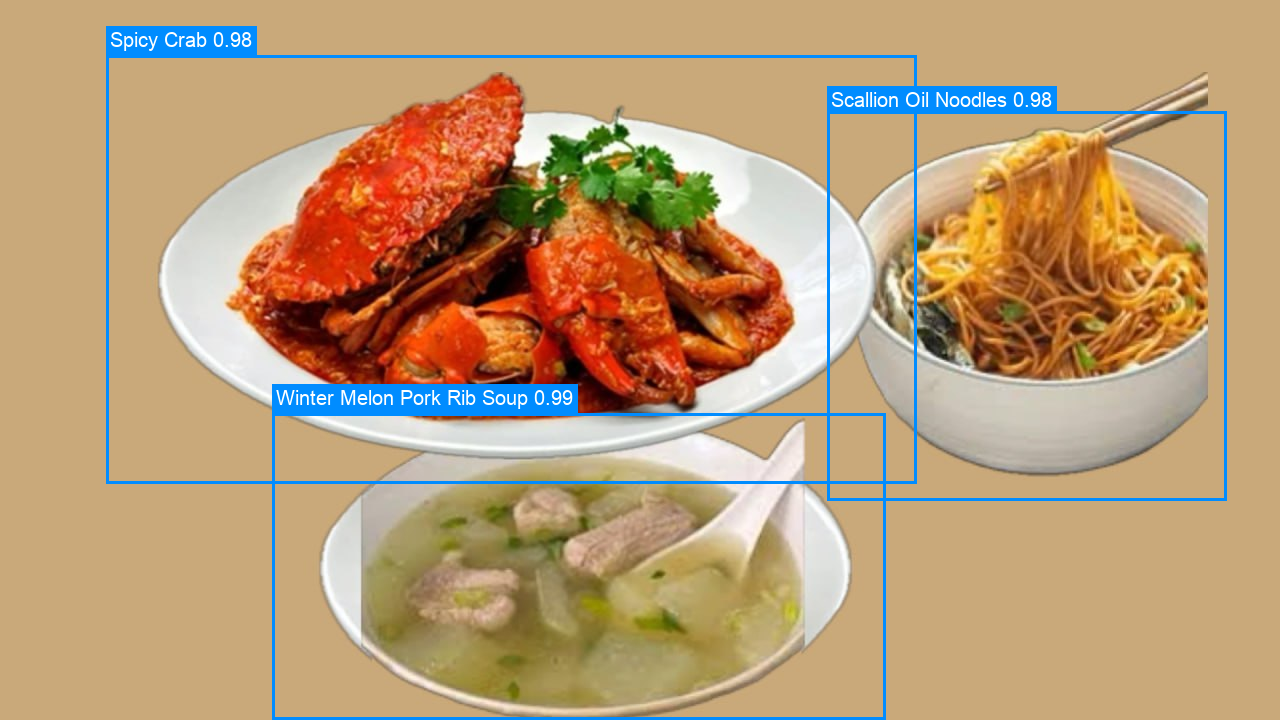

3 detections
{'box_xyxy': (106, 55, 916, 483), 'cls_id': 13, 'cls_name': 'Spicy Crab', 'score': 0.9832412004470825}
{'box_xyxy': (272, 413, 885, 719), 'cls_id': 19, 'cls_name': 'Winter Melon Pork Rib Soup', 'score': 0.9877798557281494}
{'box_xyxy': (827, 111, 1226, 500), 'cls_id': 11, 'cls_name': 'Scallion Oil Noodles', 'score': 0.9790011048316956}


In [7]:
# Single image
TEST_IMAGE = "data_clean/prediction/detection/test1.jpg"
dets, vis = detect_and_classify(TEST_IMAGE, min_box_area=3000)
display(vis)
print(f"{len(dets)} detections")
for d in dets:
    print(d)
